# Photo Clustering with CLIP + K-Means

Goal: turn 200 real photos into semantic clusters (albums) using CLIP embeddings and k-means.

Pipeline: download images → embed with CLIP → cluster with k-means → visualize albums

In [2]:
import torch
import torchvision.transforms as transforms
import clip
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from datasets import load_dataset
from sklearn.cluster import KMeans

print("torch:", torch.__version__)
print("device:", "cuda" if torch.cuda.is_available() else "cpu")

torch: 2.8.0+cpu
device: cpu


## Cell 2 — Load CLIP Model

`clip.load()` downloads the model weights on first run and caches them.
It returns two things: the model and the preprocess transform — the exact image pipeline the model expects.

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

print("Model loaded:", type(model))
print("Input resolution:", model.visual.input_resolution)
print("Embedding dimension:", model.visual.output_dim)

Model loaded: <class 'clip.model.CLIP'>
Input resolution: 224
Embedding dimension: 512


## Cell 3 — Download 250 Images from Tiny-ImageNet

200 ImageNet classes — animals, vehicles, objects, food, landscapes. Genuinely diverse.
2 images per class × 125 classes = 250 images. Streaming so we don't download the full dataset.

In [31]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

MAX_IMAGES = 250
MAX_PER_CLASS = 2

# Clear existing images
for f in DATA_DIR.glob("*.jpg"):
    f.unlink()

print("Streaming tiny-imagenet (200 classes, diverse)...")
dataset = load_dataset("zh-plus/tiny-imagenet", split="train", streaming=True)
dataset = dataset.shuffle(seed=42, buffer_size=5000)

counts_per_label = {}
count = 0

for sample in dataset:
    label = sample["label"]
    if counts_per_label.get(label, 0) >= MAX_PER_CLASS:
        continue

    img = sample["image"]
    if img.mode != "RGB":
        img = img.convert("RGB")
    img.save(DATA_DIR / f"img_{count:04d}.jpg")

    counts_per_label[label] = counts_per_label.get(label, 0) + 1
    count += 1

    if count % 50 == 0:
        print(f"  saved {count}/{MAX_IMAGES}  ({len(counts_per_label)} classes so far)")
    if count >= MAX_IMAGES:
        break

print(f"\nDone. {count} images from {len(counts_per_label)} classes.")

Streaming tiny-imagenet (200 classes, diverse)...


README.md: 0.00B [00:00, ?B/s]

c:\Users\itayg\Projects\MLDL course\.venv\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\itayg\.cache\huggingface\hub\datasets--zh-plus--tiny-imagenet. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


dataset_infos.json: 0.00B [00:00, ?B/s]

  saved 50/250  (25 classes so far)
  saved 100/250  (50 classes so far)
  saved 150/250  (75 classes so far)
  saved 200/250  (100 classes so far)
  saved 250/250  (125 classes so far)

Done. 250 images from 125 classes.


## Cell 4 — Embed All Images with CLIP

For each image: load → preprocess → encode_image → collect the 512-dim vector.
Result: a (250, 512) matrix where each row is one photo's embedding.

In [32]:
image_paths = sorted(DATA_DIR.glob("*.jpg"))
print(f"Embedding {len(image_paths)} images...")

embeddings = []

with torch.no_grad():
    for i, path in enumerate(image_paths):
        img = Image.open(path).convert("RGB")
        tensor = preprocess(img).unsqueeze(0).to(device)  # (1, 3, 224, 224)
        embedding = model.encode_image(tensor)             # (1, 512)
        embeddings.append(embedding.cpu().numpy())

        if (i + 1) % 50 == 0:
            print(f"  {i + 1}/{len(image_paths)}")

embeddings = np.vstack(embeddings)  # (200, 512)
print(f"\nEmbeddings shape: {embeddings.shape}")

Embedding 250 images...
  50/250
  100/250
  150/250
  200/250
  250/250

Embeddings shape: (250, 512)


## Cell 5 — L2 Normalize Embeddings

CLIP was trained with cosine similarity — direction matters, magnitude doesn't.
L2 normalization puts all vectors on a unit sphere, making Euclidean distance = cosine distance.
Always normalize CLIP embeddings before clustering.

In [33]:
from sklearn.preprocessing import normalize

embeddings_norm = normalize(embeddings, norm="l2")

print(f"Shape: {embeddings_norm.shape}")
print(f"Sample vector norm (should be 1.0): {np.linalg.norm(embeddings_norm[0]):.6f}")

Shape: (250, 512)
Sample vector norm (should be 1.0): 1.000000


## Cell 6 — Elbow Method: Find the Right k

Run k-means for k=2 to k=20, plot inertia vs k.
Note: food101 is semantically narrow (all food) so no clear elbow emerges — this is expected in high-dimensional embedding spaces with little semantic diversity.

  k= 2  inertia=79.3
  k= 3  inertia=76.6
  k= 4  inertia=74.0
  k= 5  inertia=72.0
  k= 6  inertia=70.9
  k= 7  inertia=69.5
  k= 8  inertia=68.6
  k= 9  inertia=67.7
  k=10  inertia=66.7
  k=11  inertia=65.9
  k=12  inertia=65.4
  k=13  inertia=64.6
  k=14  inertia=63.6
  k=15  inertia=63.0
  k=16  inertia=61.9
  k=17  inertia=62.1
  k=18  inertia=61.4
  k=19  inertia=60.5
  k=20  inertia=59.8


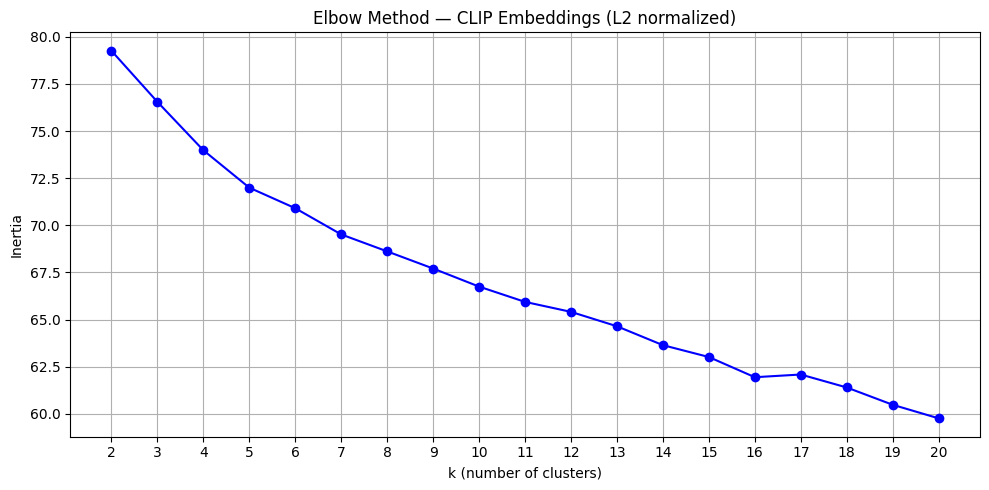

In [34]:
inertias = []
k_range = range(2, 21)

for k in k_range:
    km = KMeans(n_clusters=k, init="k-means++", random_state=42, n_init=10)
    km.fit(embeddings_norm)
    inertias.append(km.inertia_)
    print(f"  k={k:2d}  inertia={km.inertia_:.1f}")

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, "bo-")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.title("Elbow Method — CLIP Embeddings (L2 normalized)")
plt.xticks(k_range)
plt.grid(True)
plt.tight_layout()
plt.show()

# food101 is semantically narrow — all food — so no elbow emerges.
# This is expected. We'll pick k=10 based on domain knowledge.

## Cell 7 — K-Means Clustering (k=10)

No clear elbow — because food101 is semantically narrow (all food), CLIP embeddings form one dense blob with no distinct gaps between clusters. Inertia drops at a constant rate regardless of k.
We pick k=10 based on domain knowledge (food has ~10 broad categories: soups, desserts, meats, etc.).
Clustering runs on the full 512D L2-normalized embeddings.

In [35]:
K = 10

kmeans = KMeans(n_clusters=K, init="k-means++", random_state=42, n_init=10)
kmeans.fit(embeddings_norm)

labels = kmeans.labels_  # shape: (250,) — cluster index per image

for i in range(K):
    count = (labels == i).sum()
    print(f"  Cluster {i}: {count} images")

  Cluster 0: 12 images
  Cluster 1: 30 images
  Cluster 2: 26 images
  Cluster 3: 19 images
  Cluster 4: 24 images
  Cluster 5: 36 images
  Cluster 6: 17 images
  Cluster 7: 17 images
  Cluster 8: 41 images
  Cluster 9: 28 images


## Cell 8 — Visualize Clusters as Image Grid

Each row = one cluster. Each cell = an actual photo from that cluster.
Shows whether CLIP grouped semantically similar foods together.

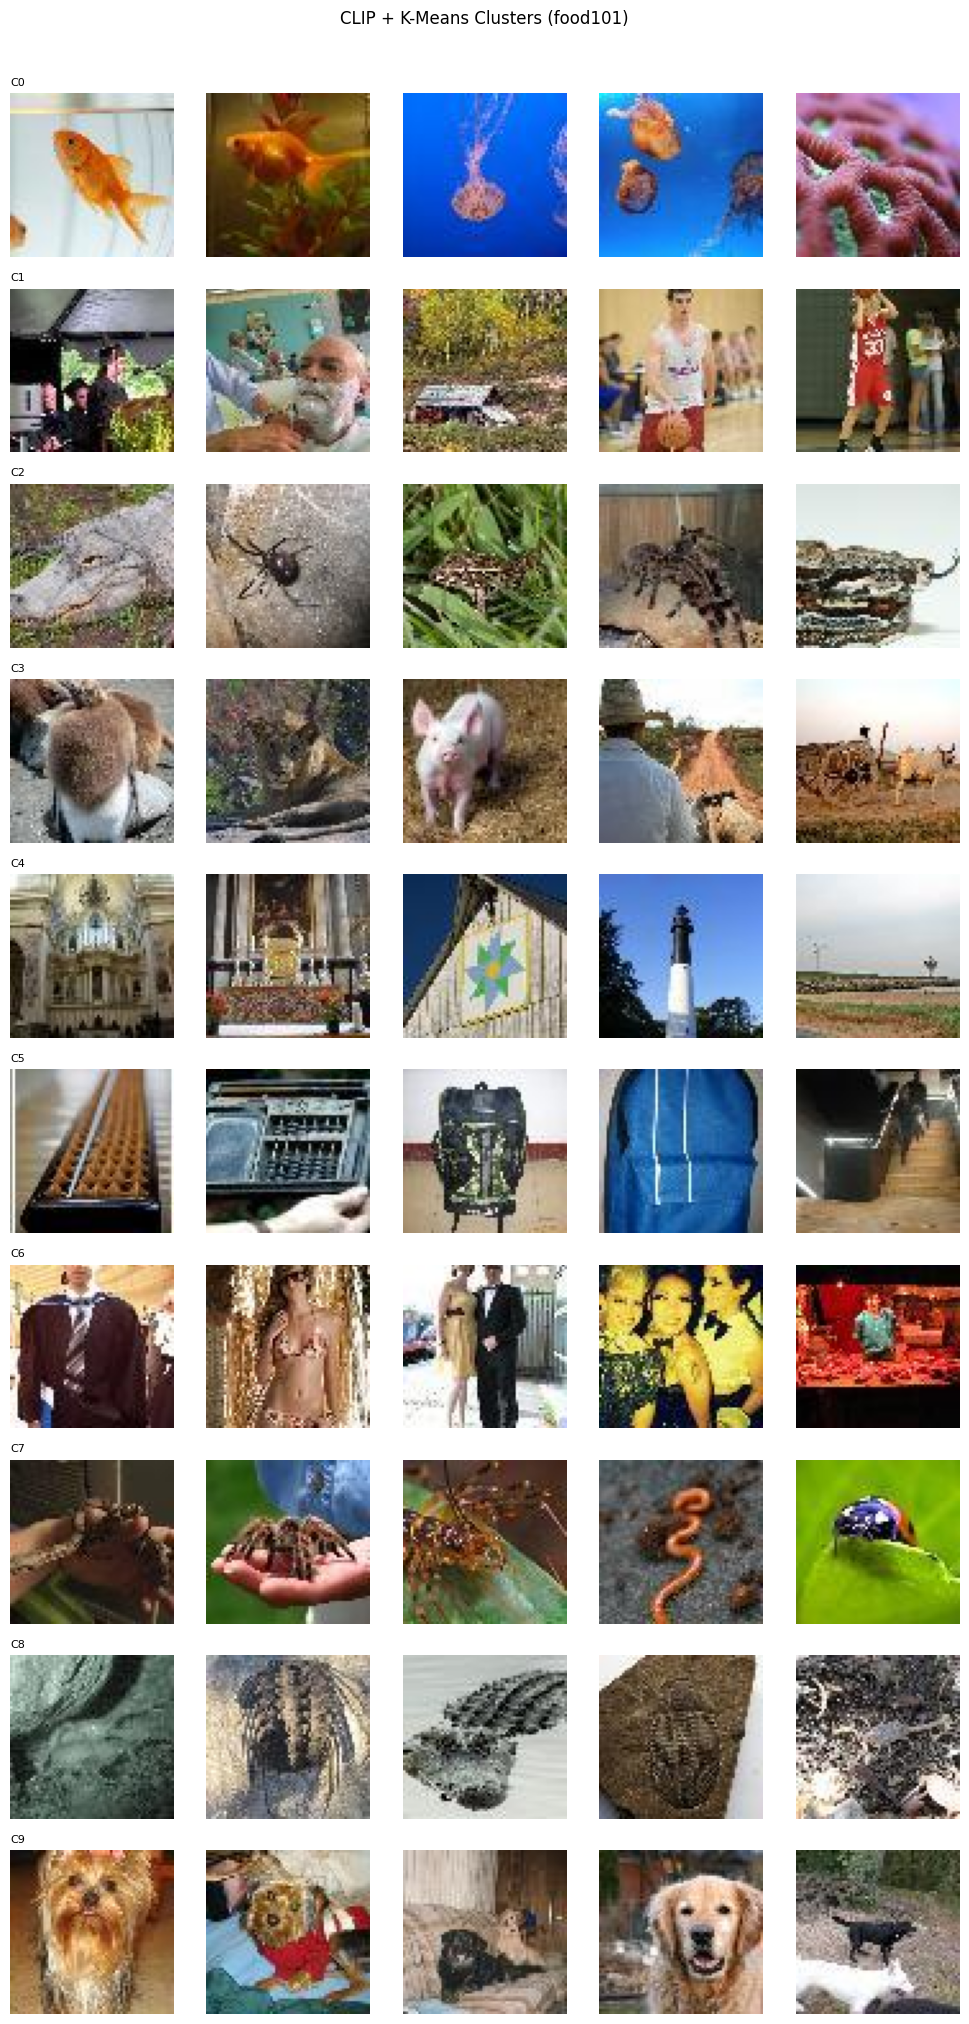

In [36]:
IMAGES_PER_ROW = 5

fig, axes = plt.subplots(K, IMAGES_PER_ROW, figsize=(IMAGES_PER_ROW * 2, K * 2))

for cluster_idx in range(K):
    cluster_image_paths = [p for p, l in zip(image_paths, labels) if l == cluster_idx]
    samples = cluster_image_paths[:IMAGES_PER_ROW]

    for col, path in enumerate(samples):
        img = Image.open(path).convert("RGB")
        axes[cluster_idx][col].imshow(img)
        axes[cluster_idx][col].axis("off")
        if col == 0:
            axes[cluster_idx][col].set_title(f"C{cluster_idx}", fontsize=8, loc="left")

    # blank out unused columns if cluster has fewer than IMAGES_PER_ROW
    for col in range(len(samples), IMAGES_PER_ROW):
        axes[cluster_idx][col].axis("off")

plt.suptitle("CLIP + K-Means Clusters (tiny-imagenet)", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Cell 9 — t-SNE Scatter Plot

PCA to 2D only captures ~12% of 512D variance — useless for visualizing clusters.
t-SNE is non-linear: finds nearest neighbors in 512D, places them close in 2D.
Points that are semantically similar in CLIP space appear as visible blobs.
Note: t-SNE axes have no meaning — only relative positions matter.

Running t-SNE (takes ~30s)...


c:\Users\itayg\Projects\MLDL course\.venv\lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


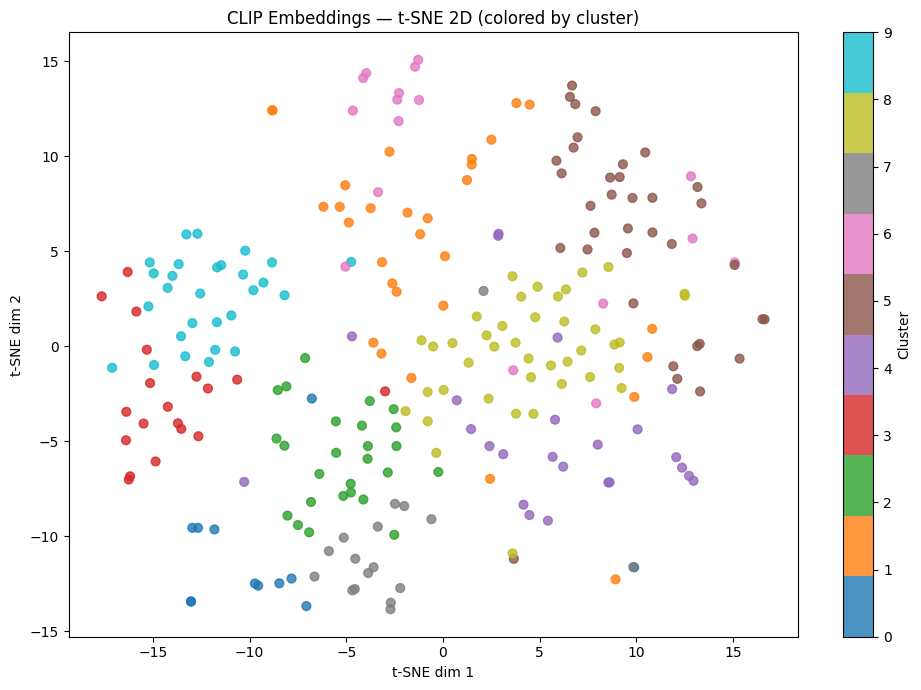

In [39]:
from sklearn.manifold import TSNE

print("Running t-SNE (takes ~30s)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
coords = tsne.fit_transform(embeddings_norm)  # (250, 2)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=labels, cmap="tab10", s=40, alpha=0.8)
plt.colorbar(scatter, label="Cluster")
plt.title("CLIP Embeddings — t-SNE 2D (colored by cluster)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.tight_layout()
plt.show()